<a href="https://colab.research.google.com/github/Handinoasa/PCVK_2026/blob/main/Week6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#PCVK Modul 6

- Nama: Handino Asa Galih
- Nim: 244107020237
- Kelas: TI 3E

# D. Praktikum Filter (Konvolusi Tanpa Library)

1. Buat fungsi konvolusi menggunakan algoritma yang telah dijelaskan pada Bagian C, tanpa
menggunakan library atau metode konvolusi dari OpenCV.  
2. langkah langkah:

    a. Buat notebook baru pada google colab, dan beri nama Week7.ipynb. Simpan Salinan pada akun github seperti pada modul sebelumnya.

    b. Akses file yang terdapat pada drive dan import beberapa library yang dibutuhkan

In [ ]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import cv2 as cv
import math
from google.colab.patches import cv2_imshow
from PIL import Image as im

# Fungsi untuk menampilkan beberapa citra secara berdampinga
def show_side_by_side(images, titles, cmap='gray'):
    plt.figure(figsize=(16, 5))
    n = len(images)
    for i in range(n):
        plt.subplot(1, n, i + 1)
        img = images[i]
        if len(img.shape) == 3 and img.shape[2] == 3:
            img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)
            plt.imshow(img_rgb)
        else:
            plt.imshow(img, cmap=cmap)
        plt.title(titles[i])
        plt.axis('off')
    plt.tight_layout()
    plt.show()


### D.1 & D.2 Fungsi Konvolusi Manual (`convolution2d`)
Fungsi ini mengimplementasikan algoritma konvolusi 2D secara eksplisit tanpa fungsi bawaan OpenCV.

In [ ]:
def convolution2d(image, kernel, stride=1, padding=0):
    # Penambahan Padding
    if padding > 0:
        padded_image = np.pad(image, ((padding, padding), (padding, padding)), mode='constant', constant_values=0)
    else:
        padded_image = image.copy()

    k_height, k_width = kernel.shape
    img_height, img_width = padded_image.shape

    # Menghitung dimensi matriks output
    out_height = (img_height - k_height) // stride + 1
    out_width = (img_width - k_width) // stride + 1

    output = np.zeros((out_height, out_width), dtype=np.float32)

    # Pergeseran kernel (sliding window)
    for y in range(0, out_height):
        for x in range(0, out_width):
            y_start = y * stride
            y_end = y_start + k_height
            x_start = x * stride
            x_end = x_start + k_width

            # Operasi perkalian elemen dan penjumlahan
            region = padded_image[y_start:y_end, x_start:x_end]
            output[y, x] = np.sum(region * kernel)

    # Pembatasan nilai piksel ke rentang 0-255
    output = np.clip(output, 0, 255).astype(np.uint8)
    return output

### D.3 Pengujian Berbagai Kernel

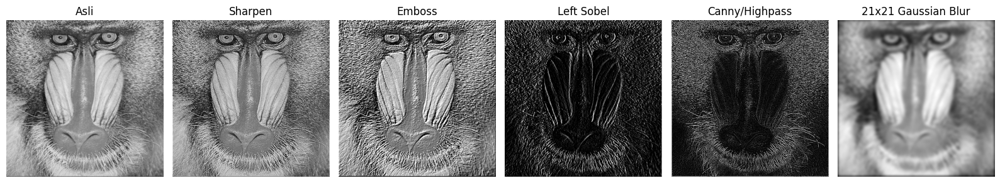

In [ ]:
# Load Citra Grayscale
img_path = '/content/drive/MyDrive/Images/mandrill.tiff'
img = cv.imread(img_path)
if img is None:
    # Menggunakan citra default OpenCV jika path drive tidak ditemukan
    img = cv.imread(cv.samples.findFile('lena.jpg'))

img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

# Definisi Matriks Kernel sesuai Modul
kernel_sharpen = np.array([[0, -1, 0],
                           [-1, 5, -1],
                           [0, -1, 0]])

kernel_emboss = np.array([[-2, -1, 0],
                          [-1, 1, 1],
                          [0, 1, 2]])

kernel_left_sobel = np.array([[1, 0, -1],
                              [2, 0, -2],
                              [1, 0, -1]])

kernel_canny = np.array([[-1, -1, -1],
                         [-1, 8, -1],
                         [-1, -1, -1]])

# Generating 21x21 Gaussian Blur Kernel
kernel_size = 21
sigma = math.sqrt(kernel_size)
gaussian_1d = cv.getGaussianKernel(kernel_size, sigma)
kernel_gaussian_21 = gaussian_1d @ gaussian_1d.transpose()

# Eksekusi Konvolusi Manual
res_sharpen = convolution2d(img_gray, kernel_sharpen, stride=1, padding=1)
res_emboss = convolution2d(img_gray, kernel_emboss, stride=1, padding=1)
res_sobel = convolution2d(img_gray, kernel_left_sobel, stride=1, padding=1)
res_canny = convolution2d(img_gray, kernel_canny, stride=1, padding=1)
res_gauss = convolution2d(img_gray, kernel_gaussian_21, stride=1, padding=10)

# Menampilkan Hasil Konvolusi Manual
show_side_by_side(
    [img_gray, res_sharpen, res_emboss, res_sobel, res_canny, res_gauss],
    ["Asli", "Sharpen", "Emboss", "Left Sobel", "Canny/Highpass", "21x21 Gaussian Blur"]
)

# E. Filter Library dan Filter Modern
### Percobaan 1: Filter Standar OpenCV (`filter2D`)

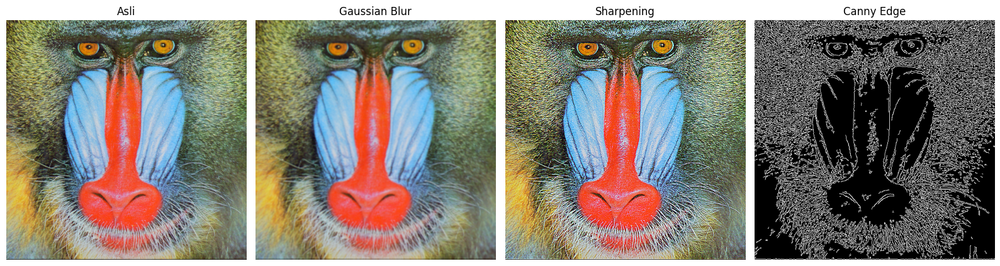

In [ ]:
# Gaussian Blur
p1_gauss = cv.GaussianBlur(img, (5, 5), 0)

# Sharpen
p1_sharpen = cv.filter2D(img, -1, kernel_sharpen)

# Canny Edge
p1_canny = cv.Canny(cv.cvtColor(img, cv.COLOR_BGR2GRAY), 100, 200)

show_side_by_side([img, p1_gauss, p1_sharpen, p1_canny], ["Asli", "Gaussian Blur", "Sharpening", "Canny Edge"])

### Percobaan 2: Filter Modern (Bilateral & Edge Preserving Filter)

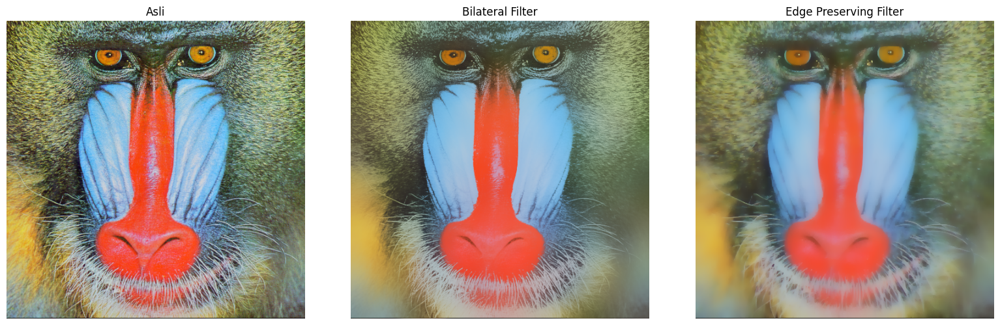

In [ ]:
# Bilateral Filter
bilateral = cv.bilateralFilter(img, d=50, sigmaColor=100, sigmaSpace=100)

# Edge Preserving Filter (Sebagai alternatif Guided Filter)
edge_preserve = cv.edgePreservingFilter(img, flags=1, sigma_s=100, sigma_r=0.9)

show_side_by_side([img, bilateral, edge_preserve], ["Asli", "Bilateral Filter", "Edge Preserving Filter"])

### Percobaan 3: Simulasi Feature Map pada CNN

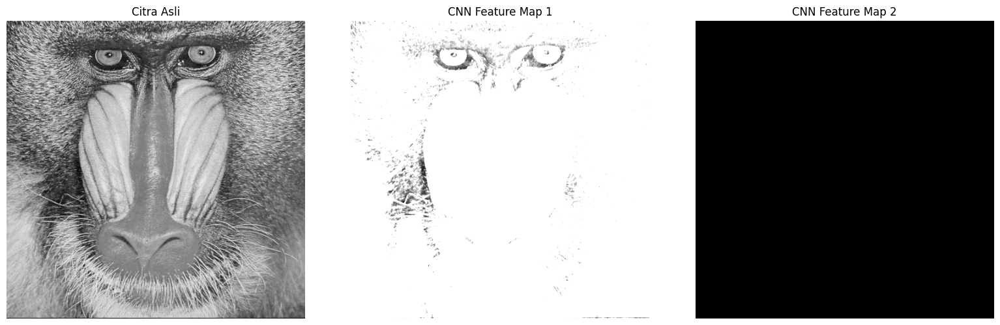

In [ ]:
# Menggunakan filter acak untuk mensimulasikan ekstraksi fitur pada Convolutional Layer CNN
np.random.seed(42)
random_kernel_1 = np.random.randn(3, 3)
random_kernel_2 = np.random.randn(3, 3)

feat_map_1 = cv.filter2D(img_gray, -1, random_kernel_1)
feat_map_2 = cv.filter2D(img_gray, -1, random_kernel_2)

show_side_by_side([img_gray, feat_map_1, feat_map_2], ["Citra Asli", "CNN Feature Map 1", "CNN Feature Map 2"])

Kesimpulan Percobaan 3: Setiap kernel/filter pada lapisan konvolusi CNN memproyeksikan citra input ke dalam ruang fitur baru yang kemudian mengekstrak informasi spesifik (seperti deteksi tepi, sudut, atau tekstur tertentu) yang relevan untuk proses klasifikasi atau deteksi objek.

### Percobaan 4: Efek Vintage Kombinasi Filter Tradisional

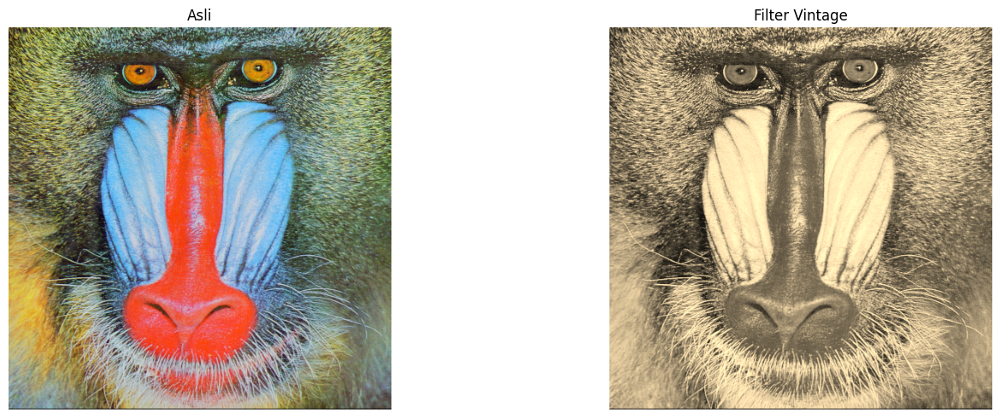

In [ ]:
def filter_vintage(image):
    # Efek sepia menggunakan kombinasi matriks transformasi warna
    kernel_sepia = np.array([[0.272, 0.534, 0.131],
                             [0.349, 0.686, 0.168],
                             [0.393, 0.769, 0.189]])
    vintage = cv.transform(image, kernel_sepia)
    vintage = np.clip(vintage, 0, 255).astype(np.uint8)
    return vintage

show_side_by_side([img, filter_vintage(img)], ["Asli", "Filter Vintage"])

### Percobaan 5: Filter Anime / Cartoon

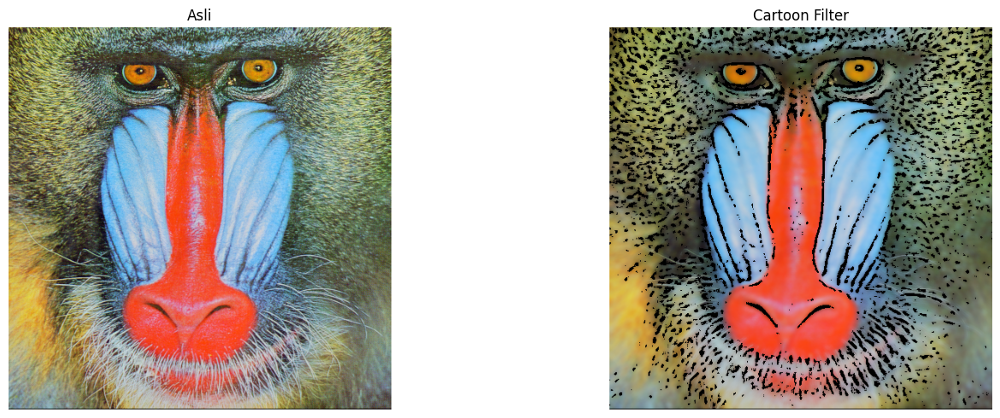

In [ ]:
# Step 1: Edge detection (menggunakan median blur dan adaptive thresholding)
gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
gray_blur = cv.medianBlur(gray, 5)
edges = cv.adaptiveThreshold(gray_blur, 255, cv.ADAPTIVE_THRESH_MEAN_C, cv.THRESH_BINARY, 9, 9)

# Step 2: Bilateral Filter untuk smoothing warna
color = cv.bilateralFilter(img, d=9, sigmaColor=200, sigmaSpace=200)

# Step 3: Penggabungan masking warna dan tepi
cartoon = cv.bitwise_and(color, color, mask=edges)

show_side_by_side([img, cartoon], ["Asli", "Cartoon Filter"])

### Percobaan 6: Night Filter

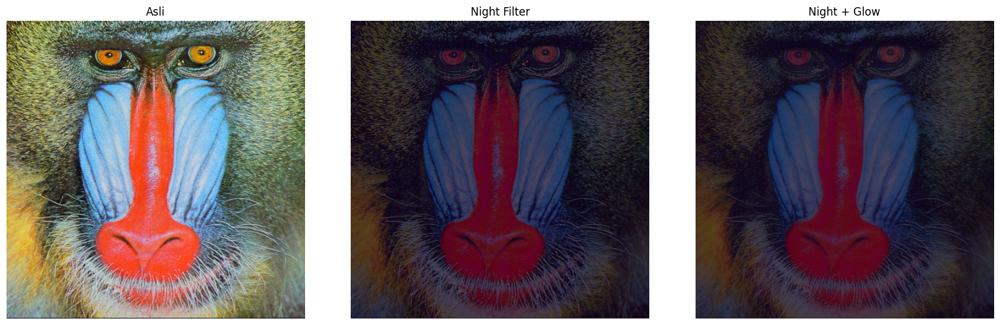

In [ ]:
# Step 1: Gelapkan citra (penurunan kontras dan brightness)
night = cv.convertScaleAbs(img, alpha=0.6, beta=-40)

# Step 2: Tambah bias warna biru (BGR)
blue_tint = np.full_like(night, (100, 0, 50))
night = cv.addWeighted(night, 0.8, blue_tint, 0.2, 0)

# Step 3: Efek glow di area terang
kernel = np.ones((15, 15), np.float32) / 225
glow = cv.filter2D(night, -1, kernel)
night_glow = cv.addWeighted(night, 0.7, glow, 0.3, 0)

show_side_by_side([img, night, night_glow], ["Asli", "Night Filter", "Night + Glow"])

### Percobaan 7: Morning & Fog Filter

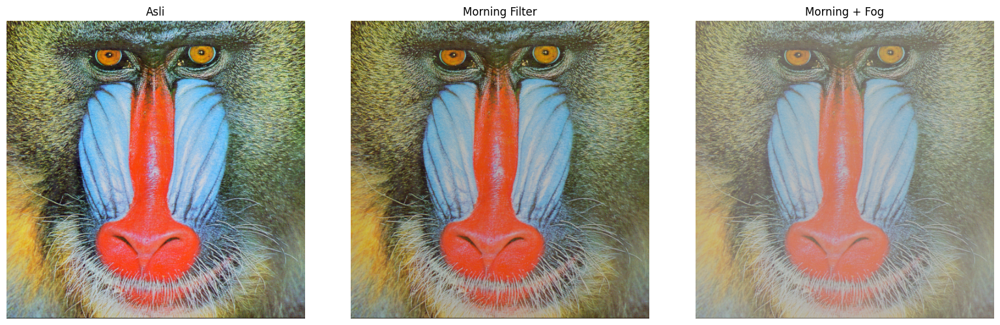

In [ ]:
# Filter Morning (Warm Sunlight effect)
warm_tint = np.full_like(img, (30, 80, 110)) # BGR bias hangat
morning = cv.addWeighted(img, 0.8, warm_tint, 0.2, 0)

# Morning Fog (Kabut Pagi)
fog_layer = np.full_like(img, (200, 200, 200)) # Layer putih transparan
morning_fog = cv.addWeighted(morning, 0.6, fog_layer, 0.4, 0)

show_side_by_side([img, morning, morning_fog], ["Asli", "Morning Filter", "Morning + Fog"])

# F. Tugas Praktikum

### 1. Tugas Analisis: Mean Filter vs. Median Filter pada Noise "Salt and Pepper"

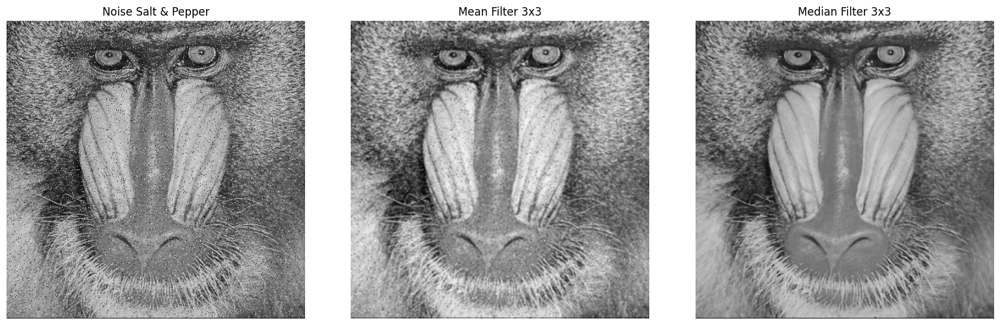

In [ ]:
# a. Menambahkan noise Salt & Pepper ke citra grayscale
def add_salt_and_pepper_noise(image, amount=0.04):
    noisy_img = image.copy()
    num_salt = np.ceil(amount * image.size * 0.5)
    coords = [np.random.randint(0, i - 1, int(num_salt)) for i in image.shape]
    noisy_img[tuple(coords)] = 255

    num_pepper = np.ceil(amount * image.size * 0.5)
    coords = [np.random.randint(0, i - 1, int(num_pepper)) for i in image.shape]
    noisy_img[tuple(coords)] = 0
    return noisy_img

noisy_image = add_salt_and_pepper_noise(img_gray, amount=0.05)

# b. Penerapan Mean Filter (3x3) dan Median Filter (3x3)
mean_filtered = cv.blur(noisy_image, (3, 3))
median_filtered = cv.medianBlur(noisy_image, 3)

show_side_by_side([noisy_image, mean_filtered, median_filtered],
                  ["Noise Salt & Pepper", "Mean Filter 3x3", "Median Filter 3x3"])

Analisis Visual & Teoritis:
- **Mean Filter** (Rata-rata): Merupakan filter linier. Saat jendela 3 X 3 mengenai piksel noise berintensitas ekstrim (0 atau 255), kemudian nilai ekstrim tersebut ikut dijumlahkan dan dibagi merata ke piksel sekitarnya. Sehingga, noise tidak hilang melainkan meredup dan menyebar menjadi bintik-bintik abu-abu buram (blur/smudge).
- **Median Filter**: Merupakan filter non-linier berbasis statistik peringkat (order-statistic). Filter ini mengurutkan seluruh nilai piksel dalam jendela tetangga dan mengambil nilai tengahnya. Karena noise salt & pepper selalu berada di batas ekstrim terendah (0) atau tertinggi (255), kemudian nilai tersebut tereliminasi dari urutan tengah sehingga piksel noise digantikan sepenuhnya oleh nilai piksel asli di sekitarnya.Maka, hasilnya jauh lebih bersih tanpa mengaburkan detail utama.

### 2. Tugas Evaluasi: Ukuran Kernel Sharpening (3 X 3 vs 5 X 5)

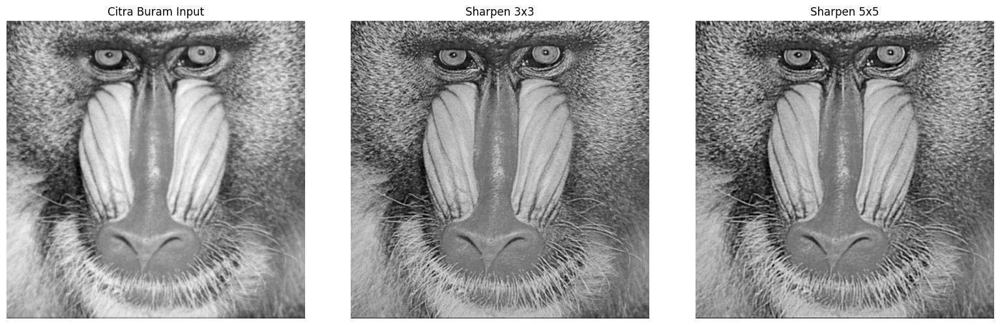

In [18]:
# a. Pembuatan Kernel Penajaman 3x3 dan 5x5
kernel_sharpen_3x3 = np.array([[0, -1, 0],
                               [-1, 5, -1],
                               [0, -1, 0]])

kernel_sharpen_5x5 = np.array([[-1, -1, -1, -1, -1],
                               [-1,  2,  2,  2, -1],
                               [-1,  2,  8,  2, -1],
                               [-1,  2,  2,  2, -1],
                               [-1, -1, -1, -1, -1]]) / 8.0

# b. Penerapan pada citra buram (blurry image)
blurry_img = cv.GaussianBlur(img_gray, (5, 5), 0)
sharp_3x3 = cv.filter2D(blurry_img, -1, kernel_sharpen_3x3)
sharp_5x5 = cv.filter2D(blurry_img, -1, kernel_sharpen_5x5)

show_side_by_side([blurry_img, sharp_3x3, sharp_5x5],
                  ["Citra Buram Input", "Sharpen 3x3", "Sharpen 5x5"])

Evaluasi & Penentuan Kernel Optimal:
- Kejelasan Tepi (Edge Sharpness): Kernel 5 X 5 memberikan tingkat penajaman tepi yang jauh lebih tinggi dan kontras batas yang lebih tajam dibandingkan kernel 3 X 3.
- Kadar Noise / Distorsi (Noise Artifacts): Kernel 5 X 5 secara berlebihan yang memperkuat komponen frekuensi tinggi pada citra, yang memicu munculnya efek halo (ringing artifact) di sepanjang garis tepi serta penguatan grain/noise yang cukup mengganggu.
- Keputusan Optimal untuk Penggunaan Sehari-hari: Kernel 3 X 3 merupakan pilihan paling ideal. Karena, kernel ini memberikan peningkatan ketajaman struktur citra yang seimbang (natural enhancement) tanpa menimbulkan distorsi visual atau memperbesar noise citra secara berlebihan.

### 3. Tugas Kreasi: Filter Kartun Sederhana (`kartun(image)`)

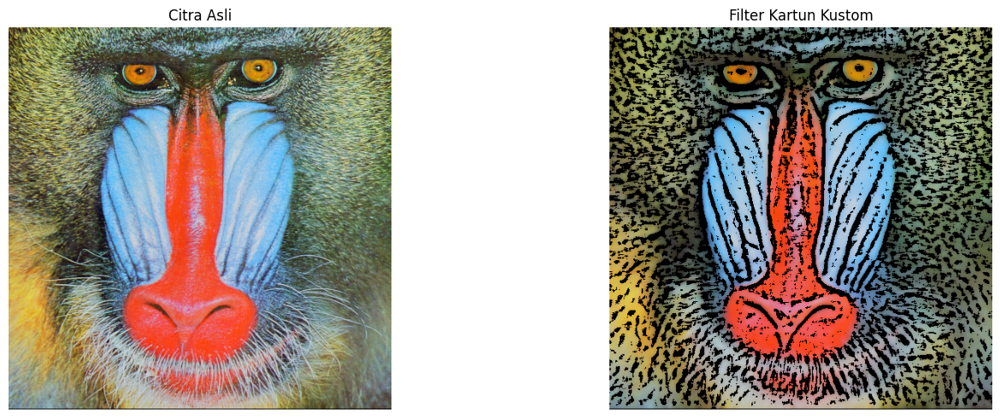

In [19]:
def kartun(image):
    """
    Fungsi kustom untuk mengubah citra menjadi efek kartun.
    Kombinasi: Bilateral Filter (Warna) + Adaptive Thresholding (Garis Tepi)
    """
    # 1. Penghalusan warna dengan Bilateral Filter untuk meratakan warna tanpa mengaburkan tepi
    color_smooth = cv.bilateralFilter(image, d=9, sigmaColor=300, sigmaSpace=300)

    # 2. Deteksi garis tepi menggunakan Adaptive Thresholding
    gray = cv.cvtColor(image, cv.COLOR_BGR2GRAY)
    gray_blur = cv.medianBlur(gray, 7)
    edges = cv.adaptiveThreshold(gray_blur, 255,
                                 cv.ADAPTIVE_THRESH_MEAN_C,
                                 cv.THRESH_BINARY,
                                 blockSize=9, C=2)

    # Konversi mask edges 1-channel ke 3-channel agar kompatibel
    edges_3channel = cv.cvtColor(edges, cv.COLOR_GRAY2BGR)

    # 3. Penggabungan dengan operasi logika perkalian piksel (bitwise AND)
    cartoon_result = cv.bitwise_and(color_smooth, edges_3channel)
    return cartoon_result

# Menampilkan Citra Asli vs Hasil Filter Kartun
cartoon_output = kartun(img)
show_side_by_side([img, cartoon_output], ["Citra Asli", "Filter Kartun Kustom"])